AnalystLab Africa Internship

Week 1-2: Data Cleaning and Exploratory Data Analysis

Datasets:
1. Online Retail Dataset
2. Netflix Movies & TV Shows Dataset

Dataset 1: Online Retail Dataset

Data Understanding

In [ ]:
--Preview the Dataset
select * from [OnlineRetail dataset]
select top 10 * from [OnlineRetail dataset]

--Row Count Query
select count (*) as Total_Rows
from [OnlineRetail dataset]

--Column Information
select COLUMN_NAME,DATA_TYPE
from INFORMATION_SCHEMA.COLUMNS
where TABLE_NAME = 'OnlineRetail dataset'

--Identification of Primary Key
select COLUMN_NAME
from INFORMATION_SCHEMA.KEY_COLUMN_USAGE
where OBJECTPROPERTY( OBJECT_ID(CONSTRAINT_NAME),
'IsPrimaryKey') = 1
and table_name = 'OnlineRetail dataset'

select count (*) as total_rows,
count (distinct InvoiceNo) as unique_invoiceno
from [OnlineRetail dataset]



Brief Description:

The dataset contains the following record: Invoice number, stockcode, decription, quantity, invoicedate, unitprice, customerid and
country
It consist of 541,909 rows and 8 columns.
Categorical variables include: description and country
Numerical variable include: invoiceno, stockcode,quantity,incoicedate,unitprice and customerid.
The primary key is Invoiceno.

In [ ]:

--Data Cleaning
--Check for missing Values
select count(*) as Total_rows,
sum(case when invoiceno is null then 1 else 0 end) as Null_invoiceno,
sum(case when Stockcode is null then 1 else 0 end) as Null_Stockcode,
sum(case when Description is null then 1 else 0 end) as Null_Description,
sum(case when Quantity is null then 1 else 0 end) as Null_Quantity,
sum(case when invoicedate is null then 1 else 0 end) as Null_invoicedate,
sum(case when unitprice is null then 1 else 0 end) as Null_unitprice,
sum(case when customerid is null then 1 else 0 end) as Null_customerid,
sum(case when country is null then 1 else 0 end) as Null_Country
from [OnlineRetail dataset]
--Investigation
-- See what these null CustomerID rows look like
select top 20 *
from [OnlineRetail dataset]
where CustomerID IS NULL

select top 20 *
from [OnlineRetail dataset]
where Description IS NULL


select top 20 *
from [OnlineRetail dataset]
where UnitPrice IS NULL

-- How many cancelled invoices exist (start with 'C')?
SELECT COUNT(*) AS cancelled_transactions
FROM [OnlineRetail dataset]
WHERE InvoiceNo LIKE 'C%'

-- How many adjustment entries exist (start with 'A')?
SELECT COUNT(*) AS adjustment_entries
FROM [OnlineRetail dataset]
WHERE InvoiceNo LIKE 'A%'

-- How many rows have negative quantity?
SELECT COUNT(*) AS negative_quantity
FROM [OnlineRetail dataset]
WHERE Quantity < 0

-- How many guest orders (NULL CustomerID but valid sale)?
SELECT COUNT(*) AS guest_orders
FROM [OnlineRetail dataset]
WHERE CustomerID IS NULL
  AND Quantity > 0
  AND UnitPrice > 0

  -- Negative quantity rows that are NOT cancellations
SELECT TOP 20 *
FROM [OnlineRetail dataset]
WHERE Quantity < 0
  AND InvoiceNo NOT LIKE 'C%'

  -- Cleaned View
CREATE VIEW vw_OnlineRetail_Clean AS
SELECT
    InvoiceNo,
    StockCode,
    ISNULL(Description, 'No Description')     AS Description,
    Quantity,
    InvoiceDate,
    UnitPrice,
    CAST(
        ISNULL(CAST(CustomerID AS NVARCHAR(10)), 'Guest')
    AS NVARCHAR(10))                           AS CustomerID,
    Country
FROM [OnlineRetail dataset]
WHERE Quantity  > 0                -- removes negatives, cancellations, adjustments
  AND UnitPrice > 0                -- removes zero-price entries
  AND InvoiceNo NOT LIKE 'A%';    -- removes bad debt adjustments
-- Verify the cleaned view
SELECT COUNT(*) AS clean_rows FROM vw_OnlineRetail_Clean

--Check for duplicates
select invoiceno, count(*)
from [OnlineRetail dataset]
group by InvoiceNo
having count(*) > 1

-- Correct duplicate check on composite key
SELECT
    InvoiceNo,
    StockCode,
    COUNT(*) AS cnt
FROM [OnlineRetail dataset]
GROUP BY InvoiceNo, StockCode
HAVING COUNT(*) > 1
ORDER BY cnt DESC;

-- Standardize date format to YYYY-MM-DD
SELECT
    CONVERT(VARCHAR(10), InvoiceDate, 120) AS InvoiceDate_Clean
FROM [OnlineRetail dataset];

CONVERT(VARCHAR(10), InvoiceDate, 120) AS InvoiceDate

-- 1. Standardize date in the cleaned view (final version)
CREATE OR ALTER VIEW vw_OnlineRetail_Clean AS
SELECT
    InvoiceNo,
    StockCode,
    ISNULL(Description, 'No Description')           AS Description,
    Quantity,
    CONVERT(VARCHAR(10), InvoiceDate, 120)           AS InvoiceDate,
    ROUND(UnitPrice, 2)                              AS UnitPrice,
    ISNULL(CAST(CustomerID AS NVARCHAR(10)), 'Guest') AS CustomerID,
    Country
FROM [OnlineRetail dataset]
WHERE Quantity  > 0
  AND UnitPrice > 0
  AND InvoiceNo NOT LIKE 'A%'
  AND InvoiceNo NOT LIKE 'C%';

-- 2. Verify final clean row count
SELECT COUNT(*) AS final_clean_rows FROM vw_OnlineRetail_Clean

## DATA CLEANING SUMMARY — OnlineRetail Dataset

### Original Dataset
- Source table : [OnlineRetail dataset]
- Raw rows     : 541,909
- Columns      : 8 (InvoiceNo, StockCode, Description,
                    Quantity, InvoiceDate, UnitPrice,
                    CustomerID, Country)


### Issues Found & Decisions Made

1. NULL VALUES
   - CustomerID : 135,080 nulls (24.93%)
     → Filled with 'Guest' — valid sales from
       unregistered customers, kept in dataset
   - Description: 1,454 nulls (0.27%)
     → Filled with 'No Description'
   - UnitPrice  : 2 nulls (0.00%)
     → Removed — adjustment entries (InvoiceNo = 'A')

2. INVALID TRANSACTIONS
   - Cancelled orders (InvoiceNo LIKE 'C%'): 9,288 rows
     → Removed — not real sales
   - Bad debt adjustments (InvoiceNo LIKE 'A%'): 3 rows
     → Removed — internal accounting entries
   - Negative quantities: 10,624 rows
     → Removed — cancellations and corrections

3. DUPLICATES
   - InvoiceNo alone is not unique (expected —
     one invoice contains multiple product lines)
   - Composite key InvoiceNo + StockCode checked
   - Cancellation rows (C prefix) excluded from view
   - Non-product codes (S, M) are legitimate repeats

4. DATA TYPE & FORMAT FIXES
   - InvoiceDate standardized to YYYY-MM-DD
     using CONVERT(VARCHAR(10), InvoiceDate, 120)
   - UnitPrice rounded to 2 decimal places
     using ROUND(UnitPrice, 2)

5. PRIMARY KEY
   - No formal PK constraint on imported table
   - Logical composite key: InvoiceNo + StockCode
   - Grain: 1 row = 1 product line per invoice

### Cleaning Method
- Raw table was NOT modified at any point
- All cleaning applied inside a SQL View:
  vw_OnlineRetail_Clean
- Clean data saved to permanent table:
  OnlineRetail_Clean

### Final Dataset
- Clean rows  : 530,099
- Rows removed: 11,810 (2.18% of raw data)
- Columns     : 8 (same structure, cleaned values)

### Cleaning Rules Applied in View

  WHERE Quantity  > 0          -- removes negatives
    AND UnitPrice > 0          -- removes zero-price
    AND InvoiceNo NOT LIKE 'A%' -- removes adjustments
    AND InvoiceNo NOT LIKE 'C%' -- removes cancellations

Exploratory Data Analysis - Online Retail

In [ ]:
SELECT SUM(Unitprice) AS Total_Revenue
FROM vw_OnlineRetail_Clean

SELECT AVG(Unitprice) as Average_Revenue
FROM vw_OnlineRetail_Clean

SELECT COUNT(CustomerId) AS Total_customers
FROM vw_OnlineRetail_Clean

SELECT MAX(Unitprice) AS Highest_Price
FROM vw_OnlineRetail_Clean

SELECT MIN(Unitprice) AS Lowest_Price
FROM vw_OnlineRetail_Clean

SELECT STDEV(Unitprice) AS Std_Dev_Sample
FROM vw_OnlineRetail_Clean

-- 1. Top Selling Products
SELECT TOP 10 StockCode,Description,
    SUM(Quantity) AS total_quantity_sold,
    COUNT(DISTINCT InvoiceNo) AS times_ordered
FROM vw_OnlineRetail_Clean
GROUP BY StockCode, Description
ORDER BY total_quantity_sold DESC


-- 2. Highest Revenue Generating Countries
SELECT TOP 10 Country,
    COUNT(DISTINCT InvoiceNo) AS total_orders,
    SUM(Quantity) AS total_items_sold,
    ROUND(SUM(Quantity * UnitPrice), 2) AS total_revenue,
    ROUND(AVG(Quantity * UnitPrice), 2) AS avg_order_value
FROM vw_OnlineRetail_Clean
GROUP BY Country
ORDER BY total_revenue DESC;


-- 3. Monthly Sales Trend
SELECT
    FORMAT(CAST(InvoiceDate AS DATE), 'yyyy-MM') AS month,
    COUNT(DISTINCT InvoiceNo) AS total_orders,
    SUM(Quantity) AS total_items_sold,
    ROUND(SUM(Quantity * UnitPrice), 2) AS monthly_revenue,
    ROUND(AVG(Quantity * UnitPrice), 2) AS avg_order_value
FROM vw_OnlineRetail_Clean
GROUP BY FORMAT(CAST(InvoiceDate AS DATE), 'yyyy-MM')
ORDER BY month;


-- 4. Most Purchased Products (by number of orders)
SELECT TOP 10 StockCode,Description,
    COUNT(DISTINCT InvoiceNo) AS times_purchased,
    SUM(Quantity) AS total_units_sold,
    ROUND(AVG(UnitPrice), 2) AS avg_unit_price,
    ROUND(SUM(Quantity * UnitPrice), 2) AS total_revenue
FROM vw_OnlineRetail_Clean
GROUP BY StockCode, Description
ORDER BY times_purchased DESC;


-- 5. CUSTOMER PURCHASING BEHAVIOUR

-- 5a. Overall customer spend summary
SELECT CustomerID,
    COUNT(DISTINCT InvoiceNo) AS total_orders,
    SUM(Quantity) AS total_items_bought,
    ROUND(SUM(Quantity * UnitPrice), 2) AS total_spent,
    ROUND(AVG(Quantity * UnitPrice), 2) AS avg_order_value,
    MIN(CAST(InvoiceDate AS DATE)) AS first_purchase,
    MAX(CAST(InvoiceDate AS DATE)) AS last_purchase
FROM vw_OnlineRetail_Clean
WHERE CustomerID != 'Guest'
GROUP BY CustomerID
ORDER BY total_spent DESC;

-- 5b. Top 10 customers by revenue
SELECT TOP 10 CustomerID,
    COUNT(DISTINCT InvoiceNo) AS total_orders,
    ROUND(SUM(Quantity * UnitPrice), 2) AS total_spent,
    ROUND(AVG(Quantity * UnitPrice), 2) AS avg_order_value
FROM vw_OnlineRetail_Clean
WHERE CustomerID != 'Guest'
GROUP BY CustomerID
ORDER BY total_spent DESC;


EXPLORATORY DATA ANALYSIS SUMMARY

- Best selling product by volume: PAPER CRAFT LITTLE
  BIRDIE (80,995 units — bulk order)
- Most consistently popular product: WHITE HANGING
  HEART T-LIGHT HOLDER (2,256 invoices)
- Highest revenue product: REGENCY CAKESTAND 3 TIER
  (£174,484)
- Dominant market: United Kingdom (£9M+ revenue)
- Best international market by order value: Netherlands
  (£121 avg per order)
- Peak sales period: December (Christmas season)
- Most valuable customer: Customer 14646 (£280,206)
- Dataset covers: Dec 2010 — Dec 2011 (1 full year)



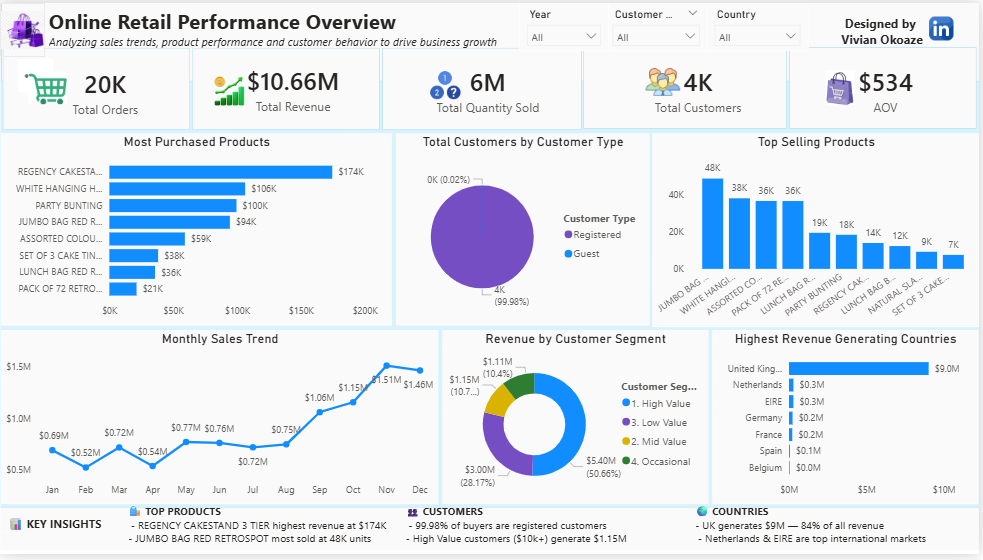

 KEY INSIGHTS

 REVENUE & ORDERS
- Total revenue of 10.66M across 20K orders
- Average order value of 533.88
- November is peak month at 1.51M (Christmas demand)
- February is the weakest month at $0.52M

 TOP PRODUCTS
- REGENCY CAKESTAND 3 TIER highest revenue at $174K
- JUMBO BAG RED RETROSPOT most sold at 48K units
- RETROSPOT brand dominates top selling products

CUSTOMERS
- 99.98% of buyers are registered customers
- Occasional buyers drive 50.66% of total revenue
- High Value customers ($10k+) generate $1.15M

COUNTRIES
- UK generates $9M — 84% of all revenue
- Netherlands & EIRE are top international markets
- Germany & France are untapped growth opportunities

 RECOMMENDATIONS
- Stock top products early ahead of Q4 surge
- Launch promotions in February to boost slow month
- Target Germany & France for international expansion
- Retain High Value customers with loyalty programme

Dataset 2: Netflix Titles Dataset

Data Understanding

In [ ]:
--Preview the Dataset
SELECT * FROM [Netflix_titles dataset]
SELECT  TOP 10 *
FROM [netflix_titles dataset]

--Row Count Query
select count (*) as Total_Rows
from [netflix_titles dataset]

--Column Information
select COLUMN_NAME,DATA_TYPE
from INFORMATION_SCHEMA.COLUMNS
where TABLE_NAME = 'netflix_titles dataset'

--Identification of Primary Key
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT show_id) AS unique_show_id
FROM [netflix_titles dataset]

Brief Description

The dataset contains: Type, title, director, cast, country, data_added, release_year, rating, duration, listed_in and description.

It consist of 8,807 rows and 12 columns.
Categorical variable include: show_id, type, title, director, cast, country, rating, duration, listed_in and description. Numerical variable include: date_added andrelease_year.

In [ ]:
-- Data Cleaning
--Check for Duplicates
SELECT title, type, COUNT(*) AS cnt
FROM [netflix_titles dataset]
GROUP BY title, type
HAVING COUNT(*) > 1
ORDER BY cnt DESC

--Check for Missing Values
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN show_id IS NULL THEN 1 ELSE 0 END) AS null_show_id,
    SUM(CASE WHEN type IS NULL THEN 1 ELSE 0 END) AS null_type,
    SUM(CASE WHEN title IS NULL THEN 1 ELSE 0 END) AS null_title,
    SUM(CASE WHEN director IS NULL THEN 1 ELSE 0 END) AS null_director,
    SUM(CASE WHEN cast IS NULL THEN 1 ELSE 0 END) AS null_cast,
    SUM(CASE WHEN country IS NULL THEN 1 ELSE 0 END) AS null_country,
    SUM(CASE WHEN date_added   IS NULL THEN 1 ELSE 0 END) AS null_date_added,
    SUM(CASE WHEN release_year IS NULL THEN 1 ELSE 0 END) AS null_release_year,
    SUM(CASE WHEN rating IS NULL THEN 1 ELSE 0 END) AS null_rating,
    SUM(CASE WHEN duration IS NULL THEN 1 ELSE 0 END) AS null_duration,
    SUM(CASE WHEN listed_in IS NULL THEN 1 ELSE 0 END) AS null_listed_in,
    SUM(CASE WHEN description IS NULL THEN 1 ELSE 0 END) AS null_description
FROM [netflix_titles dataset]

--Investigation
-- Are most missing directors from TV Shows?
SELECT type,
    COUNT(*) AS total,
    SUM(CASE WHEN director IS NULL THEN 1 ELSE 0 END) AS null_director,
    ROUND(100.0 * SUM(CASE WHEN director IS NULL THEN 1 ELSE 0 END)
          / COUNT(*), 2) AS pct_null
FROM [netflix_titles dataset]
GROUP BY type

-- Check the 3 rows with missing duration
SELECT *
FROM [netflix_titles dataset]
WHERE duration IS NULL

-- Check distinct ratings
SELECT rating, COUNT(*) AS cnt
FROM [netflix_titles dataset]
GROUP BY rating
ORDER BY cnt DESC

-- Check duration format consistency
SELECT DISTINCT
    CASE
        WHEN duration LIKE '%min%' THEN 'Minutes (Movie)'
        WHEN duration LIKE '%Season%' THEN 'Seasons (TV Show)'
        ELSE 'Unknown format'
    END AS duration_format,
    COUNT(*) AS cnt
FROM [netflix_titles dataset]
GROUP BY
    CASE
        WHEN duration LIKE '%min%' THEN 'Minutes (Movie)'
        WHEN duration LIKE '%Season%' THEN 'Seasons (TV Show)'
        ELSE 'Unknown format'
    END

--Build Clean View
CREATE VIEW vw_netflix_clean AS
SELECT
    show_id,
    LTRIM(RTRIM(type))                                        AS type,
    LTRIM(RTRIM(title))                                       AS title,
    ISNULL(NULLIF(LTRIM(RTRIM(director)),''), 'Not Listed')   AS director,
    ISNULL(NULLIF(LTRIM(RTRIM(cast)),''),     'Not Listed')   AS cast,
    ISNULL(NULLIF(LTRIM(RTRIM(country)),''),  'Unknown')      AS country,
    ISNULL(NULLIF(LTRIM(RTRIM(date_added)),''),'Unknown')     AS date_added,
    release_year,
    ISNULL(NULLIF(LTRIM(RTRIM(rating)),''),   'Not Rated')    AS rating,
    ISNULL(NULLIF(LTRIM(RTRIM(duration)),''), 'Not Available') AS duration,
    LTRIM(RTRIM(listed_in))                                   AS listed_in,
    LTRIM(RTRIM(description))                                 AS description
FROM [netflix_titles dataset]
WHERE show_id IS NOT NULL
  AND title   IS NOT NULL
  AND type    IS NOT NULL

-- Verify cleaned view
SELECT COUNT(*) AS clean_rows FROM vw_netflix_clean

-- Save as permanent table
SELECT * INTO netflix_clean
FROM vw_netflix_clean

SELECT COUNT(*) AS saved_rows FROM netflix_clean

Data Cleaning Summary

- Raw table was NOT modified at any point
- All cleaning applied inside a SQL View:
  vw_netflix_clean
- Clean data saved to permanent table:
  netflix_clean

Cleaning rules applied in view:
  1. NULL director   → filled with 'Not Listed'
  2. NULL cast       → filled with 'Not Listed'
  3. NULL country    → filled with 'Unknown'
  4. NULL date_added → filled with 'Unknown'
  5. NULL rating     → filled with 'Not Rated'
  6. NULL duration   → filled with 'Not Available'
  7. All text columns trimmed with LTRIM(RTRIM())
  8. Rows excluded only if show_id, title
     or type is NULL (none found)
     
- show_id checked: no duplicate IDs found
- title + type checked for same content listed twice

No rows were removed because all NULL values
were in non-critical columns and could be filled
with meaningful placeholder values. The core
identifiers (show_id, type, title) had zero nulls.


Exploratory Data Analysis - Netflix titles

In [ ]:
SELECT MAX(release_year) AS Highest_year
FROM vw_netflix_clean


SELECT MIN(release_year) AS Lowest_year
FROM vw_netflix_clean

SELECT COUNT(show_id) AS Total_Showid
FROM vw_netflix_clean

-- 1. Movies vs TV Shows distribution
SELECT type,
    COUNT(*)                                              AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2)    AS percentage
FROM netflix_clean
GROUP BY type

-- 2. Content Added by Year
SELECT
    YEAR(TRY_CAST(date_added AS DATE))                    AS year_added,
    COUNT(*)                                              AS titles_added,
    SUM(CASE WHEN type = 'Movie'   THEN 1 ELSE 0 END)    AS movies,
    SUM(CASE WHEN type = 'TV Show' THEN 1 ELSE 0 END)    AS tv_shows
FROM netflix_clean
WHERE TRY_CAST(date_added AS DATE) IS NOT NULL
GROUP BY YEAR(TRY_CAST(date_added AS DATE))
ORDER BY year_added

-- 3. Top Content Producing Countries
SELECT country,
    COUNT(*) AS total_titles,
    SUM(CASE WHEN type = 'Movie'   THEN 1 ELSE 0 END)    AS movies,
    SUM(CASE WHEN type = 'TV Show' THEN 1 ELSE 0 END)    AS tv_shows
FROM netflix_clean
WHERE country != 'Unknown'
GROUP BY country
ORDER BY total_titles DESC

-- 4. Most Common Ratings
SELECT
    rating,
    COUNT(*)                                              AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2)    AS percentage
FROM netflix_clean
GROUP BY rating
ORDER BY total DESC

-- 5. Most Common Genres
SELECT TOP 10
    listed_in,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2)    AS percentage
FROM netflix_clean
GROUP BY listed_in
ORDER BY total DESC


Exploratory Data Analysis Summary

Netflix is primarily an adult-oriented platform
with a movie-heavy catalogue dominated by US content.
However its fastest growing segments are international
TV Shows — particularly Korean and Japanese series —
suggesting a strategic shift toward global original
series content.


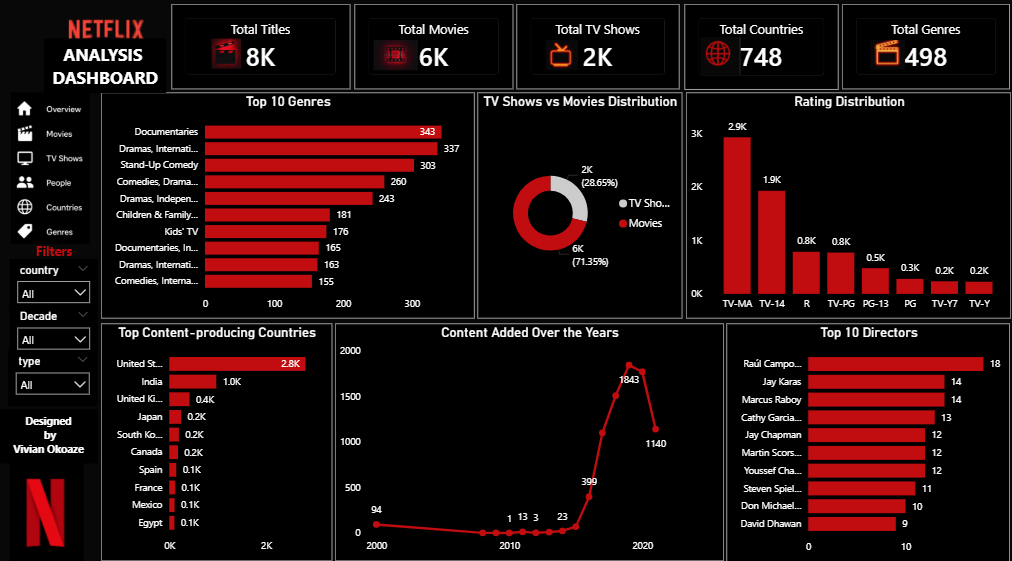

KEY INSIGHTS

 CONTENT OVERVIEW
- 9K total titles 6K Movies (69.62%)
  and 3K TV Shows (30.38%)
- Netflix is predominantly a movie platform

 TOP COUNTRIES
- United States leads with 2.8K titles (32%)
- India is strong second at 1.0K Bollywood driven
- Japan & South Korea drive TV Show content globally

 CONTENT GROWTH
- Near zero content before 2010
- Explosive growth from 2016 peaked at 1,999
  titles in 2019
- Sharp decline after 2020 COVID impact on
  production and licensing

 RATINGS
- TV-MA dominates at 3.2K (36%) adult platform
- TV-14 second at 2.2K teen audience strong
- Family content (TV-Y, TV-Y7) minimal at 0.3K each

 TOP GENRES
- Dramas & International Movies lead at 362 titles
- Documentaries strong second at 359 titles
- Stand-Up Comedy notably large at 334 titles

 TOP DIRECTORS
- Rajiv Chilaka leads with 19 titles
- Raúl Campos close second at 18 titles
- Steven Spielberg notable at 11 titles